In [1]:
pip install kaggle


In [ ]:
import os
import zipfile


!mkdir -p ~/.kaggle
!mv /kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

def download_facial_keypoints_dataset():
    if not os.path.exists("facial-keypoints-detection"):
        api = KaggleApi()
        api.authenticate()
        api.competition_download_files('facial-keypoints-detection')
        os.system("unzip facial-keypoints-detection.zip -d facial-keypoints-detection")

        print("Dataset downloaded and extracted.")
    else:
        print("Dataset already exists.")

download_facial_keypoints_dataset()
os.system("unzip /content/facial-keypoints-detection/test.zip -d /content/facial-keypoints-detection/test/")
os.system("unzip /content/facial-keypoints-detection/training.zip -d /content/facial-keypoints-detection/training/")

Dataset downloaded and extracted.


0

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


df = pd.read_csv('/content/facial-keypoints-detection/training/training.csv')
df = df.dropna()
X = np.array([np.fromstring(img, sep=' ') for img in df['Image']]) / 255.0
X = X.reshape(-1, 96, 96, 1).astype(np.float32)
y = df.drop(columns=['Image']).values.astype(np.float32)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1)

In [ ]:
keypoints_15 = [
    'left_eye_center_x', 'left_eye_center_y',
    'right_eye_center_x', 'right_eye_center_y',
    'left_eye_inner_corner_x', 'left_eye_inner_corner_y',
    'left_eye_outer_corner_x', 'left_eye_outer_corner_y',
    'right_eye_inner_corner_x', 'right_eye_inner_corner_y',
    'right_eye_outer_corner_x', 'right_eye_outer_corner_y',
    'left_eyebrow_inner_end_x', 'left_eyebrow_inner_end_y',
    'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y',
    'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y',
    'right_eyebrow_outer_end_x', 'right_eyebrow_outer_end_y',
    'nose_tip_x', 'nose_tip_y',
    'mouth_left_corner_x', 'mouth_left_corner_y',
    'mouth_right_corner_x', 'mouth_right_corner_y',
    'mouth_center_top_lip_x', 'mouth_center_top_lip_y'
]

import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


df = pd.read_csv('/content/facial-keypoints-detection/training/training.csv')


df = df[keypoints_15 + ['Image']]


df = df.dropna()


X = np.array([np.fromstring(img, sep=' ') for img in df['Image']]) / 255.0
X = X.reshape(-1, 96, 96, 1).astype(np.float32)


y = df[keypoints_15].values.astype(np.float32)
y = y / 96.0

print(f"Dataset shape: X={X.shape}, y={y.shape}")

Dataset shape: X=(2153, 96, 96, 1), y=(2153, 28)


In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(500, activation='relu'),
    layers.Dense(30)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     6,400,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │        15,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,508,202 (24.83 MB)

 Trainable params: 6,508,202 (24.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=400, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0618 - val_loss: 2.6400
Epoch 2/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2321 - val_loss: 2.3808
Epoch 3/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0978 - val_loss: 2.4699
Epoch 4/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1260 - val_loss: 2.3626
Epoch 5/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1008 - val_loss: 2.5953
Epoch 6/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1342 - val_loss: 2.4475
Epoch 7/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1596 - val_loss: 2.4466
Epoch 8/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1315 - val_loss: 2.6010
Epoch 9/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2125 - val_loss: 2.6172
Epoch 10/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1834 - val_loss: 2.4270
Epoch 11/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1146 - val_loss: 2.4564
Epoch 12/400
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

In [16]:
model.save("facial_keypoints_model.keras")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


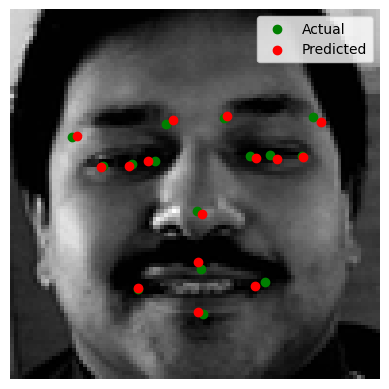

In [18]:
def show_predictions(model, X, y_true, index=0):
    image = X[index].reshape(96, 96)
    true_points = y_true[index]
    pred_points = model.predict(X[index:index+1])[0]

    plt.imshow(image, cmap='gray')
    plt.scatter(true_points[0::2], true_points[1::2], c='g', label='Actual')
    plt.scatter(pred_points[0::2], pred_points[1::2], c='r', label='Predicted')
    plt.legend()
    plt.axis('off')
    plt.show()

show_predictions(model, X_val, y_val, index=5)
